[INFO] Configurazione di riproducibilità completata con Seed: 42
Addestramento rete neurale attraverso: cpu
[INFO] Dataset caricato con successo. Numero totale di grafi: 1001

========================= FEATURE INSPECTION AND SKEWNESS ANALYSIS =========================
Feature 00 | min=-3.00 | max=7864.00 | mean=314.52 | median=169.00 | std=668.11 | skew=6.54 | unique=2169
Feature 01 | min=2.00 | max=7878.00 | mean=321.37 | median=176.00 | std=668.13 | skew=6.54 | unique=2153
Feature 02 | min=-538.00 | max=798.00 | mean=7.85 | median=6.00 | std=13.09 | skew=23.54 | unique=57
Feature 03 | min=0.00 | max=120.27 | mean=12.43 | median=10.82 | std=9.01 | skew=1.04 | unique=32568
Feature 04 | min=-1.00 | max=1.00 | mean=-0.11 | median=0.00 | std=0.59 | skew=0.03 | unique=3
Feature 05 | min=0.00 | max=215.60 | mean=2.99 | median=2.36 | std=3.76 | skew=28.97 | unique=1222
Feature 06 | min=-13.05 | max=14.42 | mean=0.48 | median=0.29 | std=1.29 | skew=0.51 | unique=871
Feature 07 | min=0.00 | ma

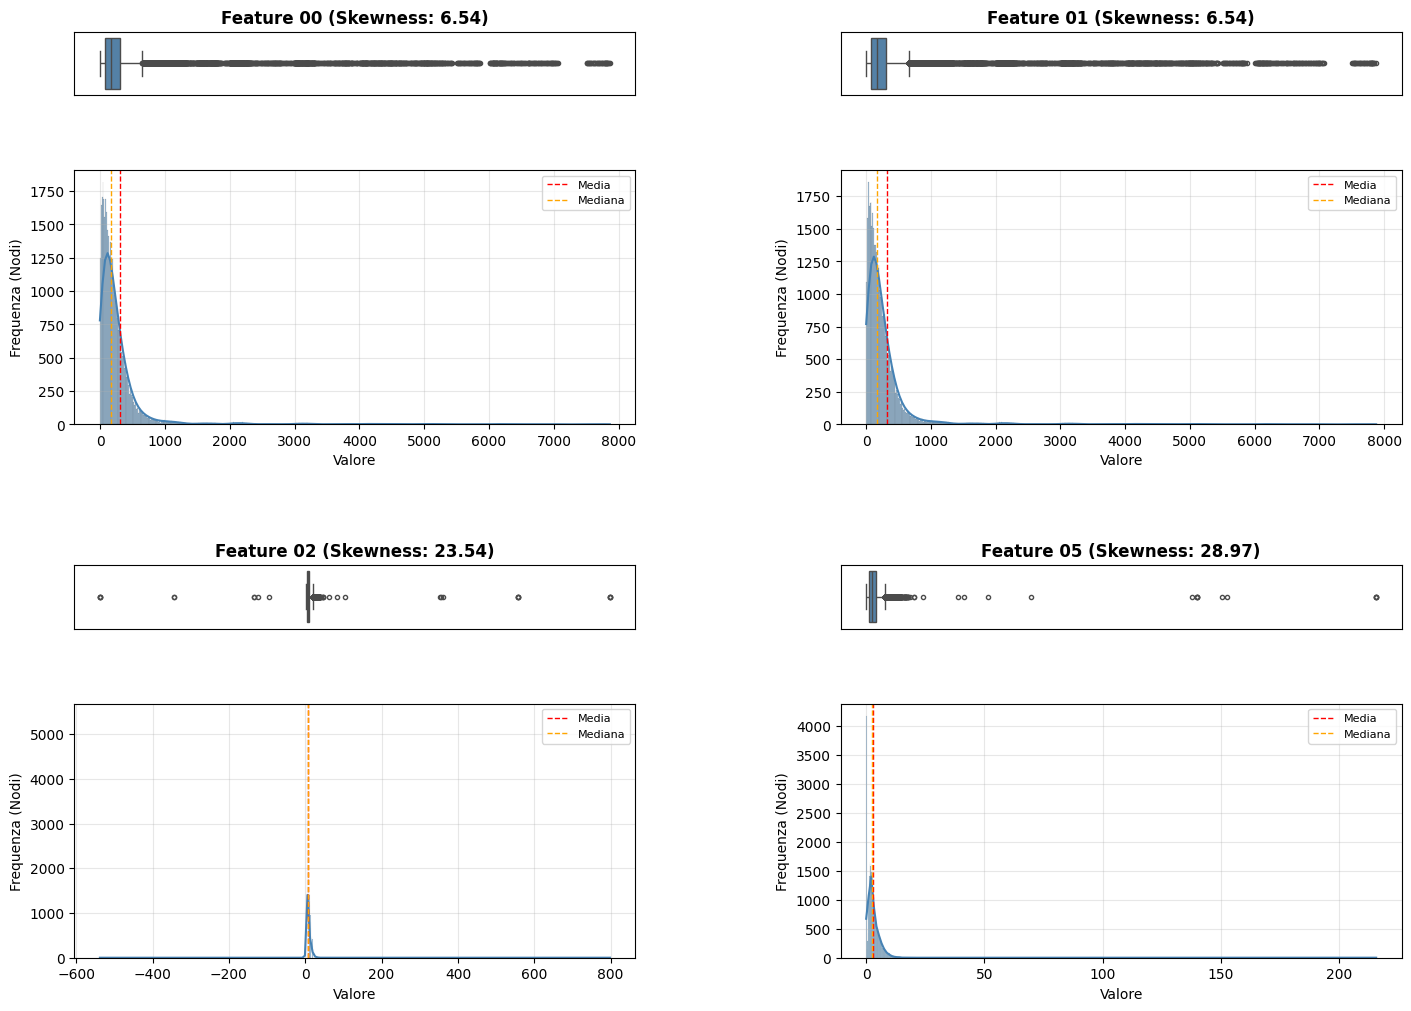

[INFO] Esportazione grafico delle distribuzioni completata.


--- ANALISI BILANCIAMENTO DATASET ---
Classe 0 (Non-Enzimi): 589 (58.84%)
Classe 1 (Enzimi)    : 412 (41.16%)
-------------------------------------

[INFO] Split Dataset completato: Train+Val = 850 grafi, Test = 151 grafi.


In [1]:
%load_ext autoreload
%autoreload 2

# Import delle librerie e dei moduli locali
from pathlib import Path
import sys
import numpy as np
import pandas as pd
from torch_geometric.loader import DataLoader
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Individuazione root del progetto per permettere gli import di 'src'
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src import config as cfg
from src import utils as ut
from src import data_loader as dl
from src import train as tr
from src import models as mdl

# Setup Riproducibilità e Device
ut.setup_reproducibility(cfg.FIXED_SEED)
device = ut.get_device()
print(f"Addestramento rete neurale attraverso: {device}")

# Caricamento e validazione dataset
dataset = dl.load_and_validate_dataset(str(cfg.DATASET_PATH))

# Analisi features
skewed_features, df_feature_stats = dl.inspect_node_features(dataset)

# Generazione ed esportazione del grafico delle distribuzioni
ut.plot_skewed_features_distributions(
    dataset=dataset, 
    feature_indices=skewed_features, 
    save_path=cfg.RESULTS_DIR / "node_features_distributions.png",
    show = True
)

# Analisi dello sbilanciamento delle classi
distribution = dl.check_class_imbalance(dataset)

# Separazione del Test Set finale (Holdout sicuro)
train_val_dataset, test_dataset = dl.stratified_holdout_split(dataset, cfg.TEST_SIZE, cfg.FIXED_SEED)

In [2]:
# Griglia di iperparametri (4 combinazioni totali per non appesantire la CPU)
grid_lr = [1e-3, 1e-4]
grid_dropout = [0.1, 0.3]

# Lista di indici delle feature da non normalizzare
excluded_indexes = [4, 29, 30, 31]

results_archive = {}

print("\n=========================================")
print("AVVIO GRID SEARCH: GCN & GAT")
print("=========================================\n")

print("\n[INFO]: Avvio procedura di Cross Validation...")
print("[INFO]: Impostata applicazione Z-Score e Noise Injection in modo isolato all'interno di ciascun fold.\n")

for model_name, model_class in [("GCN", mdl.ProteinGCN), ("GAT", mdl.ProteinGAT)]:
    # print(f"\n Valutazione Architettura: Protein{model_name}")
    print(f"\n VALUTAZIONE ARCHITETTURA: Protein{model_name}")
    for lr in grid_lr:
        for drop in grid_dropout:
            config_name = f"{model_name}_lr_{lr}_drop_{drop}"
            print(f"\n>> Testando configurazione: {config_name}")
            
            f1_res, auc_res = tr.run_cross_validation(
                dataset=train_val_dataset,
                model_class=model_class,
                n_splits=cfg.N_SPLITS,
                batch_size=cfg.DEFAULT_BATCH_SIZE,
                train_fold_fn=tr.train_single_fold,
                seed=cfg.FIXED_SEED,
                lr=lr,
                dropout_p=drop,
                hidden_channels=cfg.DEFAULT_HIDDEN_CHANNELS,
                excluded_features=excluded_indexes,
                noise_level=cfg.NOISE_LEVEL,
                use_log_transform=False,
            )
            results_archive[config_name] = {
                "model": model_name, "lr": lr, "dropout": drop, "channels": cfg.DEFAULT_HIDDEN_CHANNELS,
                "f1_mean": np.mean(f1_res), "f1_std": np.std(f1_res),
                "auc_mean": np.mean(auc_res), "auc_std": np.std(auc_res),
                "f1_scores": f1_res, "auc_scores": auc_res,
            }

print("\n[INFO]: Lavoro completato.")


AVVIO GRID SEARCH: GCN & GAT


[INFO]: Avvio procedura di Cross Validation...
[INFO]: Impostata applicazione Z-Score e Noise Injection in modo isolato all'interno di ciascun fold.


 VALUTAZIONE ARCHITETTURA: ProteinGCN

>> Testando configurazione: GCN_lr_0.001_drop_0.1

   --- FOLD 1/3 ---
   [Epoca 01/50] Training Loss: 0.6713
   [Epoca 10/50] Training Loss: 0.4323
   [Epoca 20/50] Training Loss: 0.3667
   [Epoca 30/50] Training Loss: 0.2997
   [Epoca 40/50] Training Loss: 0.2320
   [Epoca 50/50] Training Loss: 0.1542
   Risultati Fold 1 | Macro F1: 0.7297 | ROC-AUC: 0.7759

   --- FOLD 2/3 ---
   [Epoca 01/50] Training Loss: 0.6757
   [Epoca 10/50] Training Loss: 0.4744
   [Epoca 20/50] Training Loss: 0.3878
   [Epoca 30/50] Training Loss: 0.3267
   [Epoca 40/50] Training Loss: 0.2699
   [Epoca 50/50] Training Loss: 0.1825
   Risultati Fold 2 | Macro F1: 0.7380 | ROC-AUC: 0.7973

   --- FOLD 3/3 ---
   [Epoca 01/50] Training Loss: 0.6701
   [Epoca 10/50] Training Loss: 0.4604
   [E

In [3]:
df_results = pd.DataFrame.from_dict(results_archive, orient="index").sort_values(by="f1_mean", ascending=False)

# Esportazione della tabella in formato CSV
cfg.RESULTS_DIR.mkdir(exist_ok=True)
df_results.to_csv(cfg.RESULTS_DIR / "grid_search_results.csv", float_format="%.4f")

# Stampa della tabella con le informazioni di interesse
print("\n TABELLA COMPARATIVA DELLE CONFIGURAZIONI (CROSS-VALIDATION) ")
df_display = (
    df_results
    .reset_index()
    .rename(columns={'index': 'Configurazione'})
)

df_styled = (
    df_display.style
    .hide(axis="index")
    .hide(subset=["model", "lr", "dropout", "channels", "f1_scores", "auc_scores"], axis="columns")
    .format(precision=4)
)

display(df_styled)

# Estrazione automatica del modello vincente
selected_config = df_results.iloc[0]
best_model_class = mdl.ProteinGCN if selected_config["model"] == "GCN" else mdl.ProteinGAT

# print(f"selected_config: {selected_config}\n")

print("\n=======================================================================")
print(f" MODELLO VINCITORE SELEZIONATO: {selected_config.name}")
print(f" - Macro F1 Medio in CV: {selected_config['f1_mean']:.4f}")
print(f" - ROC-AUC Medio in CV: {selected_config['auc_mean']:.4f}")
print("=======================================================================\n")


 TABELLA COMPARATIVA DELLE CONFIGURAZIONI (CROSS-VALIDATION) 


Configurazione,f1_mean,f1_std,auc_mean,auc_std
GCN_lr_0.001_drop_0.3,0.7393,0.0021,0.7922,0.0091
GAT_lr_0.001_drop_0.3,0.7309,0.0192,0.7963,0.0308
GCN_lr_0.0001_drop_0.3,0.7296,0.0253,0.7973,0.0162
GAT_lr_0.0001_drop_0.1,0.7272,0.0223,0.8002,0.0325
GCN_lr_0.001_drop_0.1,0.7223,0.0166,0.7854,0.0089
GCN_lr_0.0001_drop_0.1,0.7185,0.0282,0.7888,0.0155
GAT_lr_0.001_drop_0.1,0.7090,0.0127,0.7864,0.0282
GAT_lr_0.0001_drop_0.3,0.7074,0.0274,0.8019,0.0264



 MODELLO VINCITORE SELEZIONATO: GCN_lr_0.001_drop_0.3
 - Macro F1 Medio in CV: 0.7393
 - ROC-AUC Medio in CV: 0.7922



In [4]:
# Log Trasform + Z-Score Selettiva: Test della trasformazione per mitigare la skewness.

print("=======================================================================")
print("Sperimentazione Log Trasform + Z-Score Selettiva")
print("=======================================================================")

f1_log, auc_log = tr.run_cross_validation(
    dataset=train_val_dataset,
    model_class=best_model_class,
    n_splits=cfg.N_SPLITS,
    batch_size=cfg.DEFAULT_BATCH_SIZE,
    train_fold_fn=tr.train_single_fold,
    seed=cfg.FIXED_SEED,
    lr=selected_config['lr'],
    dropout_p=selected_config['dropout'],
    hidden_channels=cfg.DEFAULT_HIDDEN_CHANNELS,
    excluded_features=excluded_indexes,
    noise_level=cfg.NOISE_LEVEL,
    use_log_transform=True # Attivazione del modulo logaritmico sicuro
)

Sperimentazione Log Trasform + Z-Score Selettiva

   --- FOLD 1/3 ---
   [Epoca 01/50] Training Loss: 0.6763
   [Epoca 10/50] Training Loss: 0.4249
   [Epoca 20/50] Training Loss: 0.3751
   [Epoca 30/50] Training Loss: 0.3075
   [Epoca 40/50] Training Loss: 0.2135
   [Epoca 50/50] Training Loss: 0.1287
   Risultati Fold 1 | Macro F1: 0.6661 | ROC-AUC: 0.7703

   --- FOLD 2/3 ---
   [Epoca 01/50] Training Loss: 0.6714
   [Epoca 10/50] Training Loss: 0.4832
   [Epoca 20/50] Training Loss: 0.4168
   [Epoca 30/50] Training Loss: 0.3510
   [Epoca 40/50] Training Loss: 0.2178
   [Epoca 50/50] Training Loss: 0.1345
   Risultati Fold 2 | Macro F1: 0.7719 | ROC-AUC: 0.8334

   --- FOLD 3/3 ---
   [Epoca 01/50] Training Loss: 0.6727
   [Epoca 10/50] Training Loss: 0.4736
   [Epoca 20/50] Training Loss: 0.4267
   [Epoca 30/50] Training Loss: 0.3571
   [Epoca 40/50] Training Loss: 0.2643
   [Epoca 50/50] Training Loss: 0.1877
   Risultati Fold 3 | Macro F1: 0.7596 | ROC-AUC: 0.8468


 -> Performance CON Log-Transform: Macro F1 Media=0.7325 | ROC-AUC Media=0.8168
 -> Performance SENZA Log-Transform: Macro F1 Media=0.7393 | ROC-AUC Media=0.7922

Δ Macro F1 Medio: -0.0068 (-0.92%)
Δ ROC-AUC Medio: +0.0246 (+3.10%)

>> Compilazione grafico comparativo...


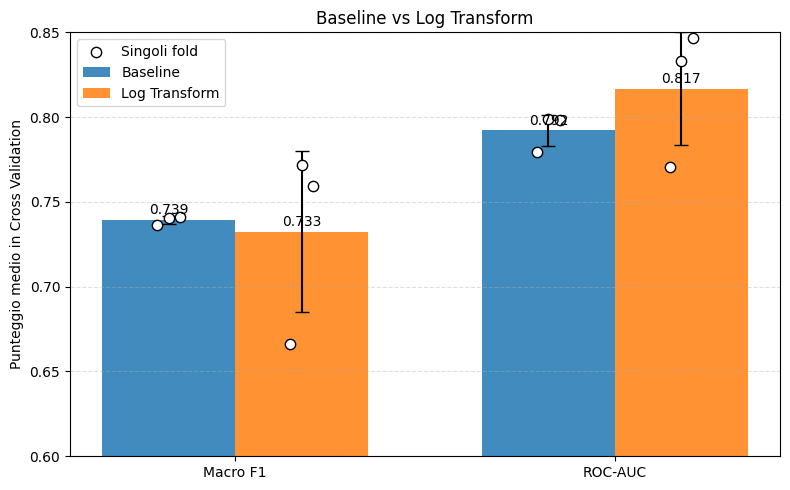

[-] Log-Transform: DISATTIVATA (Nessun beneficio)


In [5]:
print(f" -> Performance CON Log-Transform: Macro F1 Media={np.mean(f1_log):.4f} | ROC-AUC Media={np.mean(auc_log):.4f}")
print(f" -> Performance SENZA Log-Transform: Macro F1 Media={selected_config['f1_mean']:.4f} | ROC-AUC Media={selected_config['auc_mean']:.4f}")

delta_f1 = np.mean(f1_log) - selected_config["f1_mean"]
delta_auc = np.mean(auc_log) - selected_config["auc_mean"]

print(
    f"\nΔ Macro F1 Medio: {delta_f1:+.4f} ({delta_f1 / selected_config['f1_mean'] * 100:+.2f}%)"
)

print(
    f"Δ ROC-AUC Medio: {delta_auc:+.4f} ({delta_auc / selected_config['auc_mean'] * 100:+.2f}%)"
)

print("\n>> Compilazione grafico comparativo...")

baseline_scores=np.array([
    selected_config["f1_mean"],
    selected_config["auc_mean"],
])
comparison_scores=np.array([
    np.mean(f1_log),
    np.mean(auc_log),
])
baseline_std=np.array([
    selected_config["f1_std"],
    selected_config["auc_std"],
])
comparison_std=np.array([
    np.std(f1_log),
    np.std(auc_log),
])
baseline_fold_scores=[
    selected_config["f1_scores"],
    selected_config["auc_scores"],
]
comparison_fold_scores=[
    f1_log,
    auc_log,
]

ut.plot_cv_comparison(
    baseline_scores=baseline_scores,
    comparison_scores=comparison_scores,
    baseline_std=baseline_std,
    comparison_std=comparison_std,
    baseline_fold_scores = baseline_fold_scores,
    comparison_fold_scores= comparison_fold_scores,
    comparison_label="Log Transform",
    title="Baseline vs Log Transform",
    save_path=cfg.RESULTS_DIR / "test_log_transform.png",
    show = True
)

if np.mean(f1_log) > selected_config['f1_mean']:
    final_use_log = True

    current_baseline_f1 = np.mean(f1_log)
    current_baseline_auc = np.mean(auc_log)
    current_baseline_f1_std = np.std(f1_log)
    current_baseline_auc_std = np.std(auc_log)
    current_baseline_f1_scores = f1_log
    current_baseline_auc_scores = auc_log
    current_baseline_label = "Log Transform (Nuova Baseline)"

    print("[+] Log-Transform: ATTIVATA (Ha migliorato le performance)")
else:
    final_use_log = False

    current_baseline_f1 = selected_config['f1_mean']
    current_baseline_auc = selected_config['auc_mean']
    current_baseline_f1_std = selected_config['f1_std']
    current_baseline_auc_std = selected_config['auc_std']
    current_baseline_f1_scores = selected_config['f1_scores']
    current_baseline_auc_scores = selected_config['auc_scores']
    current_baseline_label = "Grid Search Baseline"
    
    print("[-] Log-Transform: DISATTIVATA (Nessun beneficio)")

In [6]:
# Test di Esclusione delle Feature One-Hot: Verifica dell'impatto della struttura secondaria.

print("\n" + "=======================================================================")
print("Test di Esclusione delle Feature One-Hot")
print("=======================================================================")

# Rimozione colonne 29, 30, 31 (Feature One-Hot)
dataset_without_onehot = dl.drop_features_permanently(train_val_dataset, indexes_to_drop=[29, 30, 31])

f1_no_onehot, auc_no_onehot = tr.run_cross_validation(
    dataset=dataset_without_onehot, # Passiamo il dataset con 29 feature totali
    model_class=best_model_class,
    n_splits=cfg.N_SPLITS,
    batch_size=cfg.DEFAULT_BATCH_SIZE,
    train_fold_fn=tr.train_single_fold,
    seed=cfg.FIXED_SEED,
    lr=selected_config['lr'],
    dropout_p=selected_config['dropout'],
    hidden_channels=cfg.DEFAULT_HIDDEN_CHANNELS,
    excluded_features=[4], # Escludiamo solo la feature categorica rimasta (la ex-04)
    noise_level=cfg.NOISE_LEVEL,
    use_log_transform=final_use_log
)


Test di Esclusione delle Feature One-Hot

   --- FOLD 1/3 ---
   [Epoca 01/50] Training Loss: 0.6949
   [Epoca 10/50] Training Loss: 0.4973
   [Epoca 20/50] Training Loss: 0.4126
   [Epoca 30/50] Training Loss: 0.3428
   [Epoca 40/50] Training Loss: 0.2658
   [Epoca 50/50] Training Loss: 0.1946
   Risultati Fold 1 | Macro F1: 0.7151 | ROC-AUC: 0.8000

   --- FOLD 2/3 ---
   [Epoca 01/50] Training Loss: 0.6852
   [Epoca 10/50] Training Loss: 0.4884
   [Epoca 20/50] Training Loss: 0.4025
   [Epoca 30/50] Training Loss: 0.3382
   [Epoca 40/50] Training Loss: 0.2696
   [Epoca 50/50] Training Loss: 0.1995
   Risultati Fold 2 | Macro F1: 0.7370 | ROC-AUC: 0.8041

   --- FOLD 3/3 ---
   [Epoca 01/50] Training Loss: 0.6822
   [Epoca 10/50] Training Loss: 0.4906
   [Epoca 20/50] Training Loss: 0.3998
   [Epoca 30/50] Training Loss: 0.3565
   [Epoca 40/50] Training Loss: 0.2822
   [Epoca 50/50] Training Loss: 0.2430
   Risultati Fold 3 | Macro F1: 0.7422 | ROC-AUC: 0.7972



 -> Modello Base Attuale (32 features): Macro F1 Media=0.7393 | ROC-AUC Media=0.7922
 -> Modello No One-Hot (29 features):   Macro F1 Media = 0.7314 | ROC-AUC Media=0.8004

Δ Macro F1 Medio: -0.0079 (-1.07%)
Δ ROC-AUC Medio: +0.0082 (+1.03%)

>> Compilazione grafico comparativo...


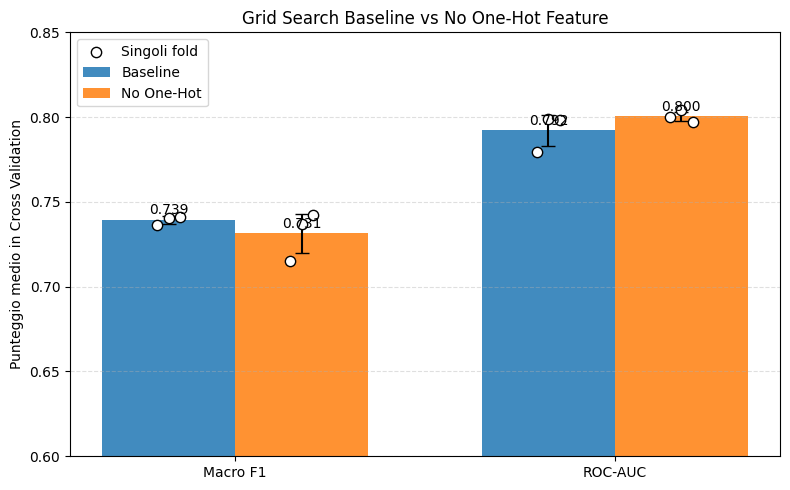

[-] Esclusione One-Hot: NON APPLICATA (Le feature aggiungono segnale utile)


In [7]:
print(f"\n -> Modello Base Attuale (32 features): Macro F1 Media={current_baseline_f1:.4f} | ROC-AUC Media={current_baseline_auc:.4f}")
print(f" -> Modello No One-Hot (29 features):   Macro F1 Media = {np.mean(f1_no_onehot):.4f} | ROC-AUC Media={np.mean(auc_no_onehot):.4f}")

delta_f1 = np.mean(f1_no_onehot) - current_baseline_f1
delta_auc = np.mean(auc_no_onehot) - current_baseline_auc

print(f"\nΔ Macro F1 Medio: {delta_f1:+.4f} ({delta_f1 / current_baseline_f1 * 100:+.2f}%)")
print(f"Δ ROC-AUC Medio: {delta_auc:+.4f} ({delta_auc / current_baseline_auc * 100:+.2f}%)")

print("\n>> Compilazione grafico comparativo...")

ut.plot_cv_comparison(
    baseline_scores=np.array([current_baseline_f1, current_baseline_auc]),
    comparison_scores=np.array([np.mean(f1_no_onehot), np.mean(auc_no_onehot)]),
    baseline_std=np.array([current_baseline_f1_std, current_baseline_auc_std]),
    comparison_std=np.array([np.std(f1_no_onehot), np.std(auc_no_onehot)]),
    baseline_fold_scores=[current_baseline_f1_scores, current_baseline_auc_scores],
    comparison_fold_scores=[f1_no_onehot, auc_no_onehot],
    comparison_label="No One-Hot",
    title=f"{current_baseline_label} vs No One-Hot Feature",
    save_path=cfg.RESULTS_DIR / "test_no_onehot.png",
    show=True
)

if np.mean(f1_no_onehot) > current_baseline_f1:
    # Utilizzo dataset "tagliato" e feature 4 unica da escludere dalla Z-Score
    final_dataset = dataset_without_onehot 
    final_excluded_indexes = [4] 

    # Aggiorniamo di nuovo la Baseline
    current_baseline_f1 = np.mean(f1_no_onehot)
    current_baseline_auc = np.mean(auc_no_onehot)
    current_baseline_f1_std = np.std(f1_no_onehot)
    current_baseline_auc_std = np.std(auc_no_onehot)
    current_baseline_f1_scores = f1_no_onehot
    current_baseline_auc_scores = auc_no_onehot
    current_baseline_label = "No One-Hot (Nuova Baseline)"

    print("[+] Esclusione One-Hot: APPLICATA (Le feature erano ridondanti)")
else:
    final_dataset = train_val_dataset
    final_excluded_indexes = [4, 29, 30, 31]
    print("[-] Esclusione One-Hot: NON APPLICATA (Le feature aggiungono segnale utile)")

In [9]:
# Ulteriore esperimento di configurazione architetturale 

print("\n=======================================================================")
print(f"Avvio analisi di sensibilità architetturale (hidden_channel: {cfg.ALT_HIDDEN_CHANNELS})")
print("=======================================================================")

f1_channels, auc_channels = tr.run_cross_validation(
    dataset=final_dataset,
    model_class=best_model_class,
    n_splits=cfg.N_SPLITS,
    batch_size=cfg.DEFAULT_BATCH_SIZE,
    train_fold_fn=tr.train_single_fold,
    seed=cfg.FIXED_SEED,
    lr=selected_config['lr'],
    dropout_p=selected_config['dropout'],
    hidden_channels=cfg.ALT_HIDDEN_CHANNELS,    # Modifica strutturale
    excluded_features=excluded_indexes,
    noise_level=cfg.NOISE_LEVEL,
    use_log_transform=final_use_log
)


Avvio analisi di sensibilità architetturale (hidden_channel: 32)

   --- FOLD 1/3 ---
   [Epoca 01/50] Training Loss: 0.6795
   [Epoca 10/50] Training Loss: 0.5230
   [Epoca 20/50] Training Loss: 0.4545
   [Epoca 30/50] Training Loss: 0.4333
   [Epoca 40/50] Training Loss: 0.3980
   [Epoca 50/50] Training Loss: 0.3548
   Risultati Fold 1 | Macro F1: 0.7238 | ROC-AUC: 0.7891

   --- FOLD 2/3 ---
   [Epoca 01/50] Training Loss: 0.6698
   [Epoca 10/50] Training Loss: 0.5211
   [Epoca 20/50] Training Loss: 0.4550
   [Epoca 30/50] Training Loss: 0.4002
   [Epoca 40/50] Training Loss: 0.3582
   [Epoca 50/50] Training Loss: 0.3116
   Risultati Fold 2 | Macro F1: 0.7602 | ROC-AUC: 0.8224

   --- FOLD 3/3 ---
   [Epoca 01/50] Training Loss: 0.6831
   [Epoca 10/50] Training Loss: 0.5344
   [Epoca 20/50] Training Loss: 0.4457
   [Epoca 30/50] Training Loss: 0.4189
   [Epoca 40/50] Training Loss: 0.4012
   [Epoca 50/50] Training Loss: 0.3464
   Risultati Fold 3 | Macro F1: 0.7396 | ROC-AUC: 0.821

 -> Performance Modello Base Attuale: Macro F1 Media=0.7393 | ROC-AUC Media=0.7922
 -> Performance con Channels=32:   Macro F1 Media = 0.7412 | ROC-AUC Media=0.8110

Δ Macro F1 Medio: +0.0019 (+0.26%)
Δ ROC-AUC Medio: +0.0187 (+2.36%)

>> Compilazione grafico comparativo...


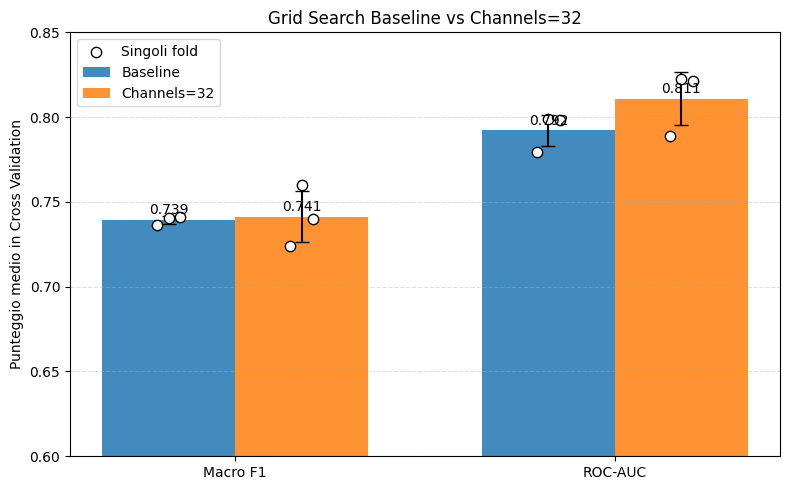

[+] STRUTTURA AGGIORNATA: Scelti 32 canali per l'addestramento finale.


In [10]:
print(f" -> Performance Modello Base Attuale: Macro F1 Media={current_baseline_f1:.4f} | ROC-AUC Media={current_baseline_auc:.4f}")
print(f" -> Performance con Channels={cfg.ALT_HIDDEN_CHANNELS}:   Macro F1 Media = {np.mean(f1_channels):.4f} | ROC-AUC Media={np.mean(auc_channels):.4f}")

delta_f1 = np.mean(f1_channels) - current_baseline_f1
delta_auc = np.mean(auc_channels) - current_baseline_auc

print(f"\nΔ Macro F1 Medio: {delta_f1:+.4f} ({delta_f1 / current_baseline_f1 * 100:+.2f}%)")
print(f"Δ ROC-AUC Medio: {delta_auc:+.4f} ({delta_auc / current_baseline_auc * 100:+.2f}%)")

print("\n>> Compilazione grafico comparativo...")

ut.plot_cv_comparison(
    baseline_scores=np.array([current_baseline_f1, current_baseline_auc]),
    comparison_scores=np.array([np.mean(f1_channels), np.mean(auc_channels)]),
    baseline_std=np.array([current_baseline_f1_std, current_baseline_auc_std]),
    comparison_std=np.array([np.std(f1_channels), np.std(auc_channels)]),
    baseline_fold_scores=[current_baseline_f1_scores, current_baseline_auc_scores],
    comparison_fold_scores=[f1_channels, auc_channels],
    comparison_label=f"Channels={cfg.ALT_HIDDEN_CHANNELS}",
    title=f"{current_baseline_label} vs Channels={cfg.ALT_HIDDEN_CHANNELS}",
    save_path=cfg.RESULTS_DIR / "test_alt_hidden_channels.png",
    show=True
)

if np.mean(f1_channels) > current_baseline_f1:
    final_channels = cfg.ALT_HIDDEN_CHANNELS
    print(f"[+] STRUTTURA AGGIORNATA: Scelti {cfg.ALT_HIDDEN_CHANNELS} canali per l'addestramento finale.")
else:
    final_channels = cfg.DEFAULT_HIDDEN_CHANNELS
    print(f"[-] STRUTTURA CONFERMATA: Mantenuti i {cfg.DEFAULT_HIDDEN_CHANNELS} canali di default.")

In [11]:
# Addestramento definitivo con configurazione migliore

print("\n==============================")
print("AVVIO ADDESTRAMENTO FINALE")
print("==============================")

print("\n[INFO]: Configurazione architetturale e pipeline di preprocessing definitiva:")

recap_data = {
    "Modello": selected_config['model'],
    "LR": f"{selected_config['lr']}",
    "Dropout": f"{selected_config['dropout']}", 
    "Hidden_channels": final_channels,
    "Epoche": cfg.DEFAULT_EPOCHS,
    "Noise": f"{cfg.NOISE_LEVEL}",
    "Log-Transform": "Attiva" if final_use_log else "Disattiva",
    "Rimozione One-Hot": "Applicata (29 feat)" if len(final_excluded_indexes) == 1 else "Non Applicata (32 feat)"
}

df_recap = pd.DataFrame([recap_data])
display(df_recap.style.hide(axis="index"))

# Lancio dell'addestramento finale
final_model, history_loss, shifts, final_mean, final_std = tr.train_final_model(    
    dataset=final_dataset,
    model_class=best_model_class,
    lr=selected_config['lr'],
    dropout_p=selected_config['dropout'],
    hidden_channels=final_channels,
    epochs=cfg.DEFAULT_EPOCHS,
    batch_size=cfg.DEFAULT_BATCH_SIZE,
    noise_level=cfg.NOISE_LEVEL,
    weight_decay = 1e-4,
    excluded_features=final_excluded_indexes,
    use_log_transform=final_use_log
)


AVVIO ADDESTRAMENTO FINALE

[INFO]: Configurazione architetturale e pipeline di preprocessing definitiva:


Modello,LR,Dropout,Hidden_channels,Epoche,Noise,Log-Transform,Rimozione One-Hot
GCN,0.001,0.3,32,50,0.01,Disattiva,Non Applicata (32 feat)


   [Epoca 01/50] Loss: 0.6828
   [Epoca 10/50] Loss: 0.5259
   [Epoca 20/50] Loss: 0.4643
   [Epoca 30/50] Loss: 0.4287
   [Epoca 40/50] Loss: 0.4039
   [Epoca 50/50] Loss: 0.3555

[INFO] Addestramento finale completato con successo.


 METRICHE DEFINITIVE SUL TEST SET (MODELLO VINCENTE) 
 - Accuracy  : 0.7815
 - Macro F1  : 0.7767  <-- Metrica di riferimento
 - Precision : 0.7164  (Capacità di evitare falsi positivi)
 - Recall    : 0.7742  (Capacità di scovare tutti gli enzimi)
 - ROC-AUC   : 0.8273


>> COMPILAZIONE GRAFICI DI VALUTAZIONE FINALI...


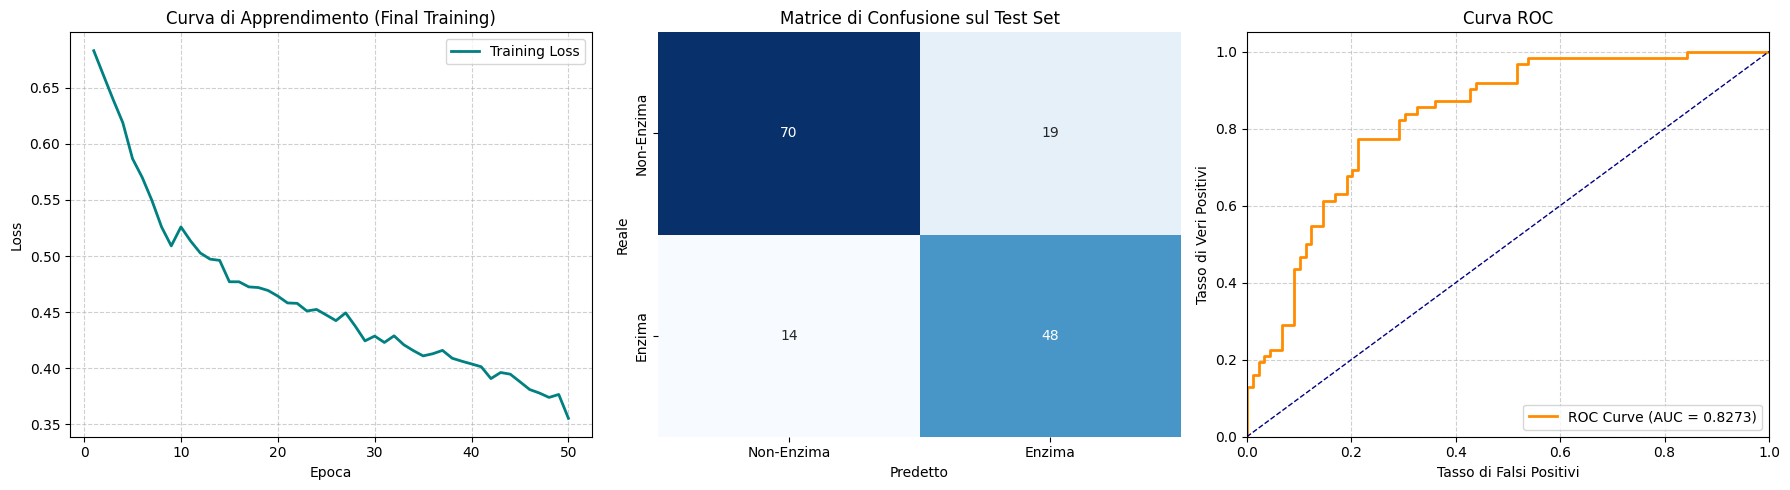

[OK] Tutti gli artefatti d'esame sono stati correttamente esportati nella cartella:
     C:\Users\edoar\Documents\UNIVERSITA'\GitHub\protein-classification-comparison\results


In [12]:
# Valutazione sul Test Set

# Rimozione feature One-Hot se attiva
if len(final_excluded_indexes) == 1: 
    test_dataset = dl.drop_features_permanently(test_dataset, indexes_to_drop=[29, 30, 31])

# Applicazione della Log-Transform (usando gli shift del train_val) se attiva
if shifts is not None:
    # Identifichiamo di nuovo le continuous_features per il Test Set
    n_features_test = test_dataset[0].x.shape[1]
    continuous_features = [i for i in range(n_features_test) if i not in final_excluded_indexes]
    test_dataset = dl.apply_safe_log_transform(test_dataset, continuous_features, shifts)

# Preparazione test set 
test_dataset_normalized = dl.apply_z_score(test_dataset, final_mean, final_std, excluded_features=final_excluded_indexes)
test_loader = DataLoader(test_dataset_normalized, batch_size=cfg.DEFAULT_BATCH_SIZE, shuffle=False, drop_last=False)

# Valutazione test set
y_test_true, y_test_pred, y_test_score = tr.evaluate_model(final_model, test_loader)

# Calcolo Metriche Definitive
acc = accuracy_score(y_test_true, y_test_pred)
f1_macro = f1_score(y_test_true, y_test_pred, average="macro")
precision = precision_score(y_test_true, y_test_pred, zero_division=0)
recall = recall_score(y_test_true, y_test_pred)
roc_auc = roc_auc_score(y_test_true, y_test_score)

# Esportazione delle metriche definitive del Test Set 
final_metrics = pd.DataFrame({
    "Accuracy": [acc],
    "Macro_F1": [f1_macro],
    "Precision": [precision],
    "Recall": [recall],
    "ROC_AUC": [roc_auc]
})

final_metrics.to_csv(
    cfg.RESULTS_DIR / "final_test_metrics.csv", index=False, float_format="%.4f"
)

print("=============================================================")
print(" METRICHE DEFINITIVE SUL TEST SET (MODELLO VINCENTE) ")
print("=============================================================")
print(f" - Accuracy  : {acc:.4f}")
print(f" - Macro F1  : {f1_macro:.4f}  <-- Metrica di riferimento")
print(f" - Precision : {precision:.4f}  (Capacità di evitare falsi positivi)")
print(f" - Recall    : {recall:.4f}  (Capacità di scovare tutti gli enzimi)")
print(f" - ROC-AUC   : {roc_auc:.4f}")
print("=============================================================\n")

ut.plot_final_evaluation_metrics(
    history_loss=history_loss,
    y_true=y_test_true,
    y_pred=y_test_pred,
    y_score=y_test_score,
    roc_auc=float(roc_auc),
    save_path=cfg.RESULTS_DIR / "final_evaluation_plots.png",
    show=True
)

print(f"[OK] Tutti gli artefatti d'esame sono stati correttamente esportati nella cartella:\n     {cfg.RESULTS_DIR.resolve()}")